## 1.- Carga y preparacion de datos

### 1.1.-Carga de librerias

In [1]:
from scipy import stats as st
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
import numpy as np
from sklearn.utils import shuffle

### 1.2.- Carga de datos

In [2]:
df = pd.read_csv("/datasets/Churn.csv", sep=",")

### 1.3.- Revision de datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [4]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8.0,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7.0,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4.0,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4.0,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2.0,134603.88,1,1,1,71725.73,0


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,9091.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,4.997690,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.894723,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,2.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Oportunidades encontradas en los datos:

Columna "Tenure" con datos ausentes: imputar los valores ausentes en Tenure con la mediana de la columna, ya que la mediana es menos sensible a los valores atípicos que la media.

Columnas RowNumber, CustomerId, y Surname no tienen un valor predictivo directo para determinar si un cliente abandona el banco: Eliminar columnas.

Columnas "Geography" y "Gender" son de tipo object (categóricas):  Los modelos de machine learning generalmente requieren entradas numéricas, por lo tanto usaremos la tecnica de OHE (One-Hot Encoding) para codificar estas variables categóricas en un formato numérico.

Columnas "CreditScore", "Age", "Balance", "NumOfProducts" y "EstimatedSalary" tienen diferentes escalas y rangos, aun que no sea absolutamente necesario escalarlos para algunos modelos basados en gradiente descendente o distancia, por ejemplo, Regresión Logística, SVM, k-NN) por lo que realizaremos la escalacion (este paso lo aplicaremos hasta hacer la divicion de datos)

### 1.4.- Imputar valores de columna "Tenure"

In [6]:
# Calcula la mediana de Tenure
median_tenure = df['Tenure'].median()

# Imputa los valores ausentes en Tenure con la mediana
df['Tenure'].fillna(median_tenure, inplace=True)

# Verifica que no queden valores nulos en Tenure
print("Valores nulos en 'Tenure' después de la imputación:", df['Tenure'].isnull().sum())

Valores nulos en 'Tenure' después de la imputación: 0


### 1.5.- Eliminacion de columnas irrelevantes

In [7]:
# Elimina las columnas irrelevantes
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Verificar las columnas restantes
print("\nColumnas restantes después de la eliminación:")
print(df.columns)


Columnas restantes después de la eliminación:
Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


### 1.6.- Codificación de variables categóricas

In [8]:
# Aplica One-Hot Encoding a las columnas 'Geography' y 'Gender'
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True) 

# Mostra las primeras filas del DataFrame con las nuevas columnas codificadas
print("\nPrimeras 5 filas del DataFrame después de One-Hot Encoding:")
print(df.head())


Primeras 5 filas del DataFrame después de One-Hot Encoding:
   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42     2.0       0.00              1          1   
1          608   41     1.0   83807.86              1          0   
2          502   42     8.0  159660.80              3          1   
3          699   39     1.0       0.00              2          0   
4          850   43     2.0  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1                  0   
1               1        112542.58       0                  0   
2               0        113931.57       1                  0   
3               0         93826.63       0                  0   
4               1         79084.10       0                  0   

   Geography_Spain  Gender_Male  
0                0            0  
1                1            0  
2                0            0  
3  

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  float64
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  uint8  
 10  Geography_Spain    10000 non-null  uint8  
 11  Gender_Male        10000 non-null  uint8  
dtypes: float64(3), int64(6), uint8(3)
memory usage: 732.5 KB


## 2.- Examinar el equilibrio de clases y entrenar el modelo sin tener en cuenta ningun desequilibrio

### 2.1 Divicion de datos

In [10]:
# características (X) y variable objetivo (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

# dataset en entrenamiento (60%), validación (20%) y prueba (20%)
# Primero, dividimos para obtener un conjunto de entrenamiento y un conjunto temporal (validación + prueba)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=12345, stratify=y) 

# Luego, dividimos el conjunto temporal en validación y prueba (50% de temp es 20% del total)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=12345, stratify=y_temp) 

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_valid: {X_valid.shape}")
print(f"Tamaño de X_test: {X_test.shape}")
print(f"Tamaño de y_train: {y_train.shape}")
print(f"Tamaño de y_valid: {y_valid.shape}")
print(f"Tamaño de y_test: {y_test.shape}")

Tamaño de X_train: (6000, 11)
Tamaño de X_valid: (2000, 11)
Tamaño de X_test: (2000, 11)
Tamaño de y_train: (6000,)
Tamaño de y_valid: (2000,)
Tamaño de y_test: (2000,)


### 2.2.- Escalado de caracteristicas numericas

In [11]:
#Identificar columnas numéricas para escalar
#Excluir las columnas binarias creadas por One-Hot Encoding y HasCrCard, IsActiveMember que ya son binarias
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

#instancia del escalador
scaler = StandardScaler()

# Entrenar el escalador SÓLO con el conjunto de entrenamiento
scaler.fit(X_train[numeric_cols])

# Transformar los conjuntos de entrenamiento, validación y prueba
X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_valid[numeric_cols] = scaler.transform(X_valid[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("\nPrimeras 5 filas de X_train después del escalado:")
print(X_train.head())


Primeras 5 filas de X_train después del escalado:
      CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
2837    -1.040434  0.953312  0.360600  0.774657      -0.914708          0   
9925     0.454006 -0.095244 -0.002786  1.910540      -0.914708          1   
8746     0.103585 -0.476537  1.087371  0.481608       0.820981          0   
660     -0.184996  0.190726 -0.002786  0.088439      -0.914708          1   
3610    -0.720933  1.620574 -1.456328  0.879129      -0.914708          1   

      IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
2837               1        -0.119110                  1                0   
9925               1        -0.258658                  0                0   
8746               1         1.422836                  0                0   
660                1        -1.160427                  1                0   
3610               0         0.113236                  0                0   

      Gender_Male  
283

/tmp/ipykernel_2373/2163100219.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1738: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value[:, i].tolist(), pi)
/tmp/ipykernel_2373/2163100219.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

### 2.3.- Examinando el desequilibrio de clases


Distribución de la clase objetivo 'Exited' en el conjunto de entrenamiento:
0    0.796333
1    0.203667
Name: Exited, dtype: float64


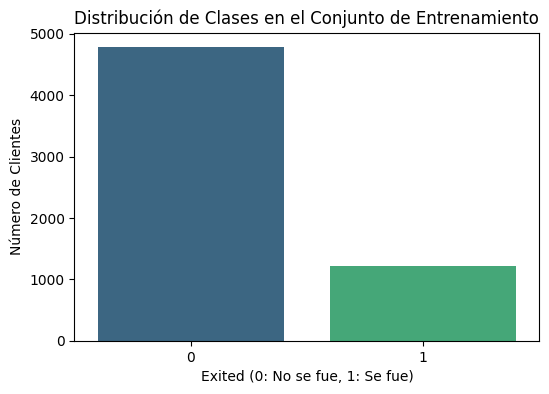

In [12]:
print("\nDistribución de la clase objetivo 'Exited' en el conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True))

# También podemos visualizarlo para mayor claridad
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette='viridis')
plt.title('Distribución de Clases en el Conjunto de Entrenamiento')
plt.xlabel('Exited (0: No se fue, 1: Se fue)')
plt.ylabel('Número de Clientes')
plt.show()

### 2.4.- Entrenando modelo sin tener en cuanta el desequilibrio

In [13]:
# Usaremos el modelo de Regresión Logística
model_base = LogisticRegression(random_state=12345, solver='liblinear')
model_base.fit(X_train, y_train)

# predicciones en el conjunto de validación
y_pred_base = model_base.predict(X_valid)

# Calcular el F1-score
f1_base = f1_score(y_valid, y_pred_base)

print(f"\nF1-score del modelo base (sin manejar el desequilibrio) en el conjunto de validación: {f1_base:.4f}")


F1-score del modelo base (sin manejar el desequilibrio) en el conjunto de validación: 0.3077


Como conclusion podemos decir que tenemos un claro desequilibrio de clases teniendo un 79.6% de clientes que no se van y un 20.3% de clientes que si se van esto es una gran diferencia lo que al correr el modelo y revisar F1 tenemos un 0.30, nosotros estariamos buscando algo arriba del 0.5.

## 3.- Mejorar la calidad del modelo

Los dos enfoque que usaremos seran:
1.- Ajuste de hiperparametros class_weight
2.- Tecnicas de remuestreo (upsampling)
Para esto usaremos el modelo de regresion logistica y arbol de decision

### 3.1.- Ajuste de hiperparametros class_weight

In [14]:
# Regresión Logística con class_weight='balanced' 
print("\nEvaluando Regresión Logística con class_weight='balanced':")
model_lr_balanced = LogisticRegression(random_state=12345, solver='liblinear', class_weight='balanced')
model_lr_balanced.fit(X_train, y_train)
y_pred_lr_balanced = model_lr_balanced.predict(X_valid)
f1_lr_balanced = f1_score(y_valid, y_pred_lr_balanced)
print(f"F1-score (Regresión Logística, balanced): {f1_lr_balanced:.4f}")

# Calcular AUC-ROC para Regresión Logística
y_proba_lr_balanced = model_lr_balanced.predict_proba(X_valid)[:, 1]
auc_roc_lr_balanced = roc_auc_score(y_valid, y_proba_lr_balanced)
print(f"AUC-ROC (Regresión Logística, balanced): {auc_roc_lr_balanced:.4f}")


Evaluando Regresión Logística con class_weight='balanced':
F1-score (Regresión Logística, balanced): 0.5290
AUC-ROC (Regresión Logística, balanced): 0.7937


In [15]:
#Arbol de Decision con class_weight='balanced' y ajuste de profundidad
print("\nEvaluando Árbol de Decisión con class_weight='balanced':")
best_f1_dt_balanced = 0
best_depth_dt_balanced = 0

for depth in range(1, 11): # Probamos profundidades de 1 a 10
    model_dt_balanced = DecisionTreeClassifier(random_state=12345, max_depth=depth, class_weight='balanced')
    model_dt_balanced.fit(X_train, y_train)
    y_pred_dt_balanced = model_dt_balanced.predict(X_valid)
    f1 = f1_score(y_valid, y_pred_dt_balanced)
    if f1 > best_f1_dt_balanced:
        best_f1_dt_balanced = f1
        best_depth_dt_balanced = depth
        best_model_dt_balanced = model_dt_balanced 

print(f"Mejor F1-score (Árbol de Decisión, balanced): {best_f1_dt_balanced:.4f} con max_depth={best_depth_dt_balanced}")

# Calcular AUC-ROC para el mejor Árbol de Decisión
y_proba_dt_balanced = best_model_dt_balanced.predict_proba(X_valid)[:, 1]
auc_roc_dt_balanced = roc_auc_score(y_valid, y_proba_dt_balanced)
print(f"AUC-ROC (Árbol de Decisión, balanced): {auc_roc_dt_balanced:.4f}")


Evaluando Árbol de Decisión con class_weight='balanced':
Mejor F1-score (Árbol de Decisión, balanced): 0.5759 con max_depth=6
AUC-ROC (Árbol de Decisión, balanced): 0.8233


al usar class_weight='balanced' el algoritmo le da mas peso a la muestra minoritaria y como podemos observar el F1 aumenta considerablemente.

### 3.2.- Tecnicas de remuestreo (upsampling)

In [16]:
#creamos una función para realizar el upsampling
def upsample(features, target, repeat):
    # Separa las clases
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    # Aumenta la clase minoritaria
    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    # Mezclar los datos para que las clases no estén secuenciadas
    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )

    return features_upsampled, target_upsampled

print("\nUsando Upsampling")

# Determinamos cuantas veces necesitamos repetir la clase minoritaria
# para que esté (aproximadamente) balanceada con la clase mayoritaria.
# Multiplicamos por 3 o 4 veces, dado que la proporción actual es ~4:1 (0.79/0.20)
count_class_0 = y_train.value_counts()[0]
count_class_1 = y_train.value_counts()[1]
repeat_factor = int(round(count_class_0 / count_class_1)) # Calcular el factor de repetición

print(f"Factor de repetición para upsampling: {repeat_factor}")

X_train_upsampled, y_train_upsampled = upsample(X_train, y_train, repeat_factor)

print(f"Distribución de clases después de upsampling en el entrenamiento:")
print(y_train_upsampled.value_counts(normalize=True))


Usando Upsampling
Factor de repetición para upsampling: 4
Distribución de clases después de upsampling en el entrenamiento:
1    0.50569
0    0.49431
Name: Exited, dtype: float64


In [17]:
#Regresion Logistica con Upsampling 
print("\nEvaluando Regresion Logistica con Upsampling:")
model_lr_upsampled = LogisticRegression(random_state=12345, solver='liblinear')
model_lr_upsampled.fit(X_train_upsampled, y_train_upsampled)
y_pred_lr_upsampled = model_lr_upsampled.predict(X_valid)
f1_lr_upsampled = f1_score(y_valid, y_pred_lr_upsampled)
print(f"F1-score (Regresion Logística, upsampled): {f1_lr_upsampled:.4f}")

# Calcular AUC-ROC para Regresión Logística con Upsampling
y_proba_lr_upsampled = model_lr_upsampled.predict_proba(X_valid)[:, 1]
auc_roc_lr_upsampled = roc_auc_score(y_valid, y_proba_lr_upsampled)
print(f"AUC-ROC (Regresión Logística, upsampled): {auc_roc_lr_upsampled:.4f}")


Evaluando Regresion Logistica con Upsampling:
F1-score (Regresion Logística, upsampled): 0.5247
AUC-ROC (Regresión Logística, upsampled): 0.7938


In [18]:
#arbol de Decisión con Upsampling y ajuste de profundidad ---
print("\nEvaluando Árbol de Decisión con Upsampling:")
best_f1_dt_upsampled = 0
best_depth_dt_upsampled = 0

for depth in range(1, 11): # Probamos profundidades de 1 a 10
    model_dt_upsampled = DecisionTreeClassifier(random_state=12345, max_depth=depth)
    model_dt_upsampled.fit(X_train_upsampled, y_train_upsampled)
    y_pred_dt_upsampled = model_dt_upsampled.predict(X_valid)
    f1 = f1_score(y_valid, y_pred_dt_upsampled)
    if f1 > best_f1_dt_upsampled:
        best_f1_dt_upsampled = f1
        best_depth_dt_upsampled = depth
        best_model_dt_upsampled = model_dt_upsampled

print(f"Mejor F1-score (Árbol de Decision, upsampled): {best_f1_dt_upsampled:.4f} con max_depth={best_depth_dt_upsampled}")

# Calcular AUC-ROC para el mejor arbol de Decisión con Upsampling
y_proba_dt_upsampled = best_model_dt_upsampled.predict_proba(X_valid)[:, 1]
auc_roc_dt_upsampled = roc_auc_score(y_valid, y_proba_dt_upsampled)
print(f"AUC-ROC (Árbol de Decisión, upsampled): {auc_roc_dt_upsampled:.4f}")


Evaluando Árbol de Decisión con Upsampling:
Mejor F1-score (Árbol de Decision, upsampled): 0.5759 con max_depth=6
AUC-ROC (Árbol de Decisión, upsampled): 0.8233


Resumen:
*Modelo Base (sin manejo de desequilibrio):
F1-score: 0.3077

*Usando class_weight='balanced':
Regresión Logística:
F1-score: 0.5290
AUC-ROC: 0.7937
Árbol de Decisión:
Mejor F1-score: 0.5759 (con max_depth=6)
AUC-ROC: 0.8233

*Usando Upsampling:
Regresión Logística:
F1-score: 0.5247
AUC-ROC: 0.7938
Árbol de Decisión:
Mejor F1-score: 0.5759 (con max_depth=6)
AUC-ROC: 0.8233

Podemos concluir que con class_weight y upsmpling mejora significativamente el resultado del F1-score.
Hasta ahora el mejor modelo es el de Arbol de decisiones, y estamos a dos centecimas de nuetro objetivo que es F1 = 0.59, nosotros alcanzamos un 0.57.

Para la prueba final usaremos "class_wight" por su simplicidad y el modelo de arbol de deciciones porque obtuvimos los mejores resultados.

## 4.- Prueba final

In [19]:
#arbol de decisión con max_depth=6 y class_weight='balanced'
final_model = DecisionTreeClassifier(random_state=12345, max_depth=6, class_weight='balanced')
final_model.fit(X_train, y_train)

# Realizamos predicciones en el conjunto de prueba
y_pred_final = final_model.predict(X_test)

# Calculamos el F1-score final
f1_final = f1_score(y_test, y_pred_final)

# Calculamos las probabilidades para AUC-ROC
y_proba_final = final_model.predict_proba(X_test)[:, 1]
auc_roc_final = roc_auc_score(y_test, y_proba_final)

print(f"\nResultados de la Prueba Final del Modelo:")
print(f"F1-score en el conjunto de prueba: {f1_final:.4f}")
print(f"AUC-ROC en el conjunto de prueba: {auc_roc_final:.4f}")

# Comprobar si se cumple el objetivo de F1-score
if f1_final >= 0.59:
    print("\n¡Felicidades! El F1-score del modelo cumple con el requisito de 0.59 o más.")
else:
    print(f"\nEl F1-score ({f1_final:.4f}) no alcanzó el requisito de 0.59. Se podría considerar probar otros modelos o técnicas de ajuste.")


Resultados de la Prueba Final del Modelo:
F1-score en el conjunto de prueba: 0.5304
AUC-ROC en el conjunto de prueba: 0.8007

El F1-score (0.5304) no alcanzó el requisito de 0.59. Se podría considerar probar otros modelos o técnicas de ajuste.


No alcanzamos nuetro resultado esperado en F1 sin embargo el AUC es muy bueno 0.8 lo que indica que  tiene una buena capacidad para distinguir entre las clases positivas (clientes que se van) y negativas (clientes que no se van), por esta razon realizaremos un ajuste en el umbral como ultima prueba sino cambiaremos de modelo.

### 4.1.- Ajuste de Umbral

In [20]:
model_for_threshold_tuning = DecisionTreeClassifier(random_state=12345, max_depth=6, class_weight='balanced')
model_for_threshold_tuning.fit(X_train, y_train)

# Obtener las probabilidades de predicción para la clase positiva (1) en el conjunto de VALIDACIÓN
probabilities_valid = model_for_threshold_tuning.predict_proba(X_valid)[:, 1]

best_f1_threshold = 0
best_threshold = 0

# Iterar sobre un rango de umbrales
for threshold in np.arange(0.0, 1.0, 0.01):
    # Convertir probabilidades a predicciones binarias usando el umbral actual
    predictions_valid = (probabilities_valid > threshold).astype(int)

    # Calcular el F1-score
    f1 = f1_score(y_valid, predictions_valid)

    # Si el F1-score actual es mejor que el mejor encontrado hasta ahora, actualizar
    if f1 > best_f1_threshold:
        best_f1_threshold = f1
        best_threshold = threshold

print(f"\nMejor F1-score encontrado en el conjunto de validación: {best_f1_threshold:.4f}")
print(f"Mejor umbral para el F1-score: {best_threshold:.2f}")

# --- Prueba Final con el Mejor Umbral ---
print("\n--- Prueba Final con el Umbral Óptimo ---")

# Obtener las probabilidades de predicción para la clase positiva (1) en el conjunto de PRUEBA
probabilities_test = model_for_threshold_tuning.predict_proba(X_test)[:, 1]

# Realizar predicciones en el conjunto de prueba usando el umbral óptimo
y_pred_final_tuned = (probabilities_test > best_threshold).astype(int)

# Calcular el F1-score final con el umbral ajustado
f1_final_tuned = f1_score(y_test, y_pred_final_tuned)

# Calcular el AUC-ROC con las probabilidades originales (no cambia con el umbral)
auc_roc_final_tuned = roc_auc_score(y_test, probabilities_test)

# Calcular Precision y Recall para entender el F1-score
precision_final_tuned = precision_score(y_test, y_pred_final_tuned)
recall_final_tuned = recall_score(y_test, y_pred_final_tuned)

print(f"\nResultados de la Prueba Final con el Umbral Ajustado ({best_threshold:.2f}):")
print(f"F1-score en el conjunto de prueba: {f1_final_tuned:.4f}")
print(f"Precision en el conjunto de prueba: {precision_final_tuned:.4f}")
print(f"Recall en el conjunto de prueba: {recall_final_tuned:.4f}")
print(f"AUC-ROC en el conjunto de prueba: {auc_roc_final_tuned:.4f}") # Este valor debería ser el mismo que antes

# Comprobar si se cumple el objetivo de F1-score
if f1_final_tuned >= 0.59:
    print("\n¡Felicidades! El F1-score del modelo cumple con el requisito de 0.59 o más después del ajuste de umbral.")
else:
    print(f"\nEl F1-score ({f1_final_tuned:.4f}) aún no alcanzó el requisito de 0.59 después del ajuste de umbral.")


Mejor F1-score encontrado en el conjunto de validación: 0.6105
Mejor umbral para el F1-score: 0.64

--- Prueba Final con el Umbral Óptimo ---

Resultados de la Prueba Final con el Umbral Ajustado (0.64):
F1-score en el conjunto de prueba: 0.5648
Precision en el conjunto de prueba: 0.5141
Recall en el conjunto de prueba: 0.6265
AUC-ROC en el conjunto de prueba: 0.8007

El F1-score (0.5648) aún no alcanzó el requisito de 0.59 después del ajuste de umbral.


Seguimos sin alcanzar el objetivo por lo que probaremos con RandomForest

### 4.2.- Cambio de modelo

In [22]:
#Buscamos lo mejores hiperparametos 
best_f1_rf = 0
best_n_estimators = 0
best_max_depth_rf = 0
best_model_rf = None

# Definir rangos para los hiperparametros
n_estimators_range = [50, 100, 150, 200] # Numero de zrboles
max_depth_range = [None, 5, 6, 7, 8, 9, 10] # Profundidad máxima de cada árbol

print("Iniciando busqueda de hiperparametros para Random Forest...")

for n_estimators in n_estimators_range:
    for depth in max_depth_range:
        model_rf = RandomForestClassifier(
            random_state=12345,
            n_estimators=n_estimators,
            max_depth=depth,
            class_weight='balanced', 
            
        )
        model_rf.fit(X_train, y_train)
        y_pred_rf = model_rf.predict(X_valid)
        f1 = f1_score(y_valid, y_pred_rf)

        if f1 > best_f1_rf:
            best_f1_rf = f1
            best_n_estimators = n_estimators
            best_max_depth_rf = depth
            best_model_rf = model_rf # Guardar el mejor modelo

print(f"\nMejor F1-score de Random Forest en validación: {best_f1_rf:.4f}")
print(f"Mejores hiperparametros: n_estimators={best_n_estimators}, max_depth={best_max_depth_rf}")

# Calcular AUC-ROC para el mejor Random Forest encontrado
y_proba_rf_best_model = best_model_rf.predict_proba(X_valid)[:, 1]
auc_roc_rf_best_model = roc_auc_score(y_valid, y_proba_rf_best_model)
print(f"AUC-ROC del mejor Random Forest en validacion: {auc_roc_rf_best_model:.4f}")

Iniciando busqueda de hiperparametros para Random Forest...

Mejor F1-score de Random Forest en validación: 0.6490
Mejores hiperparametros: n_estimators=100, max_depth=10
AUC-ROC del mejor Random Forest en validacion: 0.8711


Como conclusion de todo lo realizado podemos ver que solo con hacer el cambio de algoritmo tuvimos un mejor resultado, y claro que haber aplicado el class_weight ayudo bastante ademas es mas facil de aplicar, es importante destacar que con el nuevo modelo se tarda considerablemente en correrlo, si tuvieramos una cantidad de datos mucho mayor podriamos tomar en cuenta tambien el tiempo de corrida del modelo. En este ultimo ya no hice el ajuste de ubmbral por los buenos resultados que obtunvimos, sin embargo con el ajuste de umbral podriamos mejorar aun mas el modelo.